Continuacion del 2do ejercico del segundo parcial

In [ ]:
import numpy as np

# calculo moda :
def moda(y: int, n: int, alpha: int, beta: int) -> float:
    return (y + alpha - 1) / (n + alpha + beta - 2)

# calculo de la 2da deriv I{th}
def segunda_derivada(moda: float, y: int, n: int, alpha: int, beta: int) -> float:
    term1 = (y + alpha - 1) / (moda ** 2)
    term2 = (n - y + beta - 1) / ((1 - moda) ** 2)
    return -(term1 + term2)

# Values
n = 10
y = 6 #7
alpha = 3
betha = 2

# obtengo moda
m = moda(y, n, alpha, betha)

# Calcular la segunda derivada
I = -segunda_derivada(m, y, n, alpha, betha)

# desv estándar aprox
std_aprox = np.sqrt(1 / I)

print(f'Moda de la posterior: {m}')
print(f'Desv estandar de la aprox normal: {std_aprox}')


Moda de la posterior: 0.6153846153846154
Desviación estándar de la aproximación normal: 0.1349320029703122


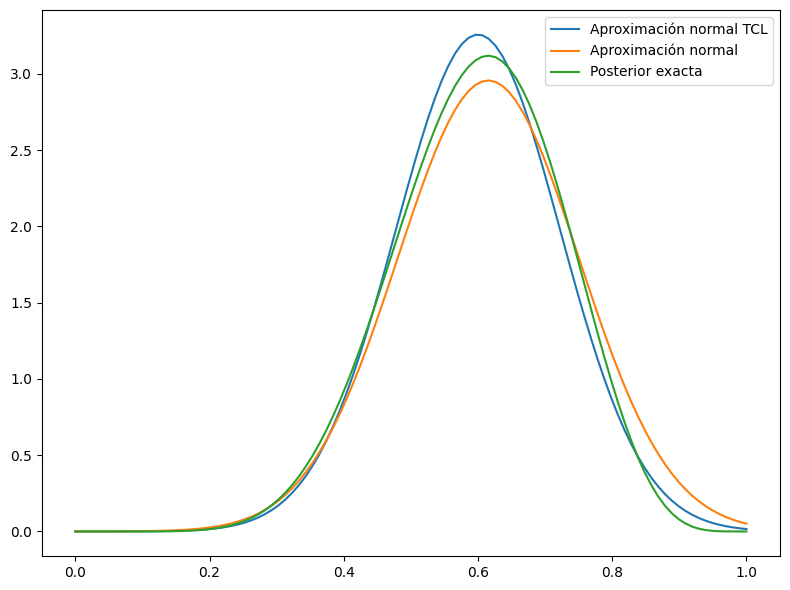

In [ ]:
# comparando graficos
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import norm

x = np.linspace(0, 1, 100)

# alpha prima y betha prima 
alpha_p = y + alpha 
betha_p = n - y + betha 

#aprox
normal_tcl = norm.pdf(x, 
                            alpha_p / (alpha_p + betha_p), 
                            np.sqrt(alpha_p * betha_p / ((alpha_p + betha_p)**2 * (alpha_p + betha_p + 1))))

#aprox momentos
normal = norm.pdf(x, 
                    m,
                    std_aprox)
#dis beta
exacta = beta.pdf(x, 
                    y + alpha, 
                    n - y + betha)

# Grafico
plt.figure(figsize=(7, 14))
plt.plot(x, normal_tcl, label='Aproximación normal TCL')
plt.plot(x, normal, label='Aproximación normal')
plt.plot(x, exacta, label='Posterior exacta')
plt.legend()
plt.tight_layout()
plt.show()